# Crop Yield / Production Prediction — Full Analysis & Model Development

Same workflow as the crop recommendation and fertilizer notebooks: EDA, outlier/signal checks,
feature engineering (evaluated, not blindly applied), a wide model comparison, tuning, final
evaluation, and export.

**Dataset:** `crop_production.csv` — district-wise, season-wise, year-wise Indian crop statistics
(246,091 rows), sourced from data.gov.in. This is a **regression** task (predict a number), unlike
the two classification models before it.

**What's different about this dataset:** it's aggregated government statistics, not lab/sensor
readings — it needs real data cleaning (missing target values, whitespace bugs, extreme skew) before
any modeling can start, and the target spans many different crop types whose production scales
differ by orders of magnitude for genuine agronomic reasons (a sugarcane field yields vastly more
tonnage per hectare than a pulse field) — so `Crop` has to be treated as a first-class feature, not
an afterthought.


## 1. Imports & setup

In [48]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Load & inspect the data

In [49]:
df_raw = pd.read_csv(r"E:\Intern\Smart-Crop-Advisory-Platform\Notebook\Dataset\crop_production.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [50]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


### 2.1 Missing values & duplicates

In [51]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicate rows: 0


3,730 rows have a missing `Production` — that's our **target column**, so there's nothing
legitimate to impute it with (guessing a yield value would just be inventing training labels). These
rows are dropped, not filled.

In [52]:
df = df_raw.dropna(subset=["Production"]).copy()
print("Rows after dropping missing target:", len(df), f"({len(df_raw) - len(df)} dropped)")


Rows after dropping missing target: 242361 (3730 dropped)


### 2.2 A whitespace bug, same category as the one caught in the fertilizer notebook

In [53]:
print("Season raw values:")
print(df["Season"].unique())


Season raw values:
['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']


`'Kharif     '` has trailing whitespace baked in — the same silent-duplicate-category issue as
`Soil_color` in the fertilizer dataset. Stripped below, along with every other text column, before
any encoding happens.

In [54]:
str_cols = df.select_dtypes(include="object").columns.tolist()
for c in str_cols:
    df[c] = df[c].str.strip()

print("Season after cleaning:", sorted(df["Season"].unique()))


Season after cleaning: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']


### 2.3 Sanity check on Area and Production values

In [55]:
print("Area <= 0 rows:", (df["Area"] <= 0).sum())
print("Production < 0 rows:", (df["Production"] < 0).sum())
print("Production == 0 rows:", (df["Production"] == 0).sum(), f"out of {len(df)}")


Area <= 0 rows: 0
Production < 0 rows: 0
Production == 0 rows: 3523 out of 242361


No negative or zero-area rows to worry about. **3,523 rows report exactly zero production** —
these are kept, not dropped: a failed harvest, a negligible-scale plot, or a genuinely unproductive
season are all real agricultural outcomes, not data errors, and we have no evidence to justify
treating them as such. Silently dropping them would bias the model toward only ever predicting
successful harvests.

## 3. Exploratory Data Analysis

### 3.1 Categorical feature cardinality

In [56]:
for col in ["State_Name", "District_Name", "Season", "Crop"]:
    print(f"{col:15s}: {df[col].nunique()} unique values")


State_Name     : 33 unique values
District_Name  : 646 unique values
Season         : 6 unique values
Crop           : 124 unique values


`District_Name` has 646 unique values — far too many to one-hot encode without exploding the
feature space (and many districts have very few rows, so per-district categories would be noisy).
`State_Name` (33) and `Crop` (124) are both large but manageable. We test in Section 5 whether
`District_Name` is worth including at all before deciding how (or whether) to encode it.

### 3.2 Coverage of the long tail — Crop

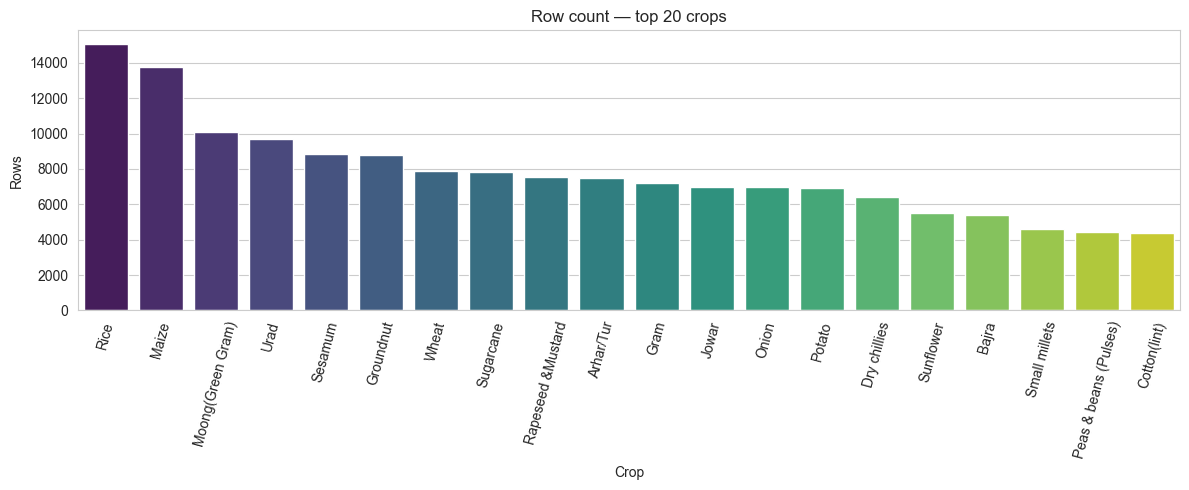

Crops needed to cover 90% of all rows: 39 (out of 124 total)
Crops with fewer than 20 rows total: 19


In [57]:
crop_counts = df["Crop"].value_counts()
coverage = crop_counts.cumsum() / len(df) * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=crop_counts.head(20).index, y=crop_counts.head(20).values, palette="viridis")
plt.xticks(rotation=75)
plt.title("Row count — top 20 crops")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

n_needed_90 = (coverage < 90).sum() + 1
n_rare = (crop_counts < 20).sum()
print(f"Crops needed to cover 90% of all rows: {n_needed_90} (out of {df['Crop'].nunique()} total)")
print(f"Crops with fewer than 20 rows total: {n_rare}")


**Known limitation, stated plainly:** roughly 19 crops have fewer than 20 rows each across the
*entire* 15+ year dataset — there's essentially no way for any model to learn a reliable pattern for
those specific crops. We keep them in (dropping real data isn't the fix), but predictions for these
long-tail crops should be treated with much lower confidence in the app than predictions for the ~40
crops that make up 90% of the data.

### 3.3 Rows per year, per season, per state

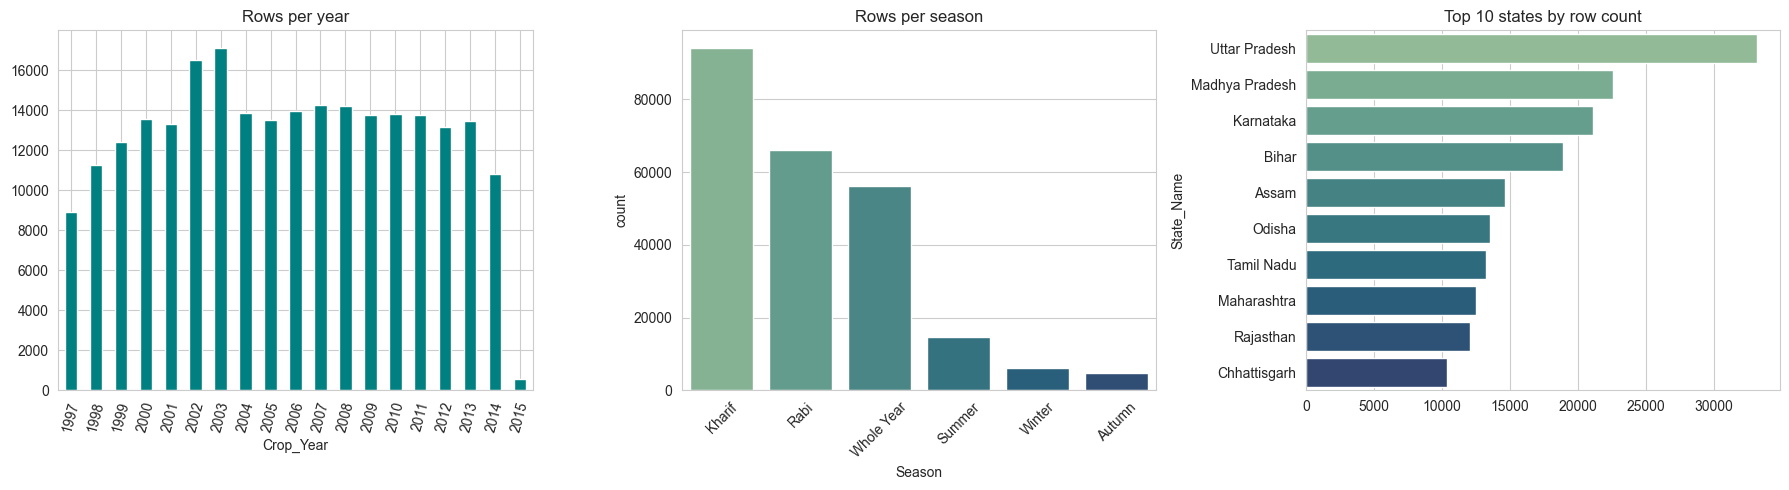

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df["Crop_Year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Rows per year")
axes[0].tick_params(axis="x", rotation=75)

sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index, ax=axes[1], palette="crest")
axes[1].set_title("Rows per season")
axes[1].tick_params(axis="x", rotation=45)

top_states = df["State_Name"].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=axes[2], palette="crest")
axes[2].set_title("Top 10 states by row count")
plt.tight_layout()
plt.show()


### 3.4 Target distribution — Production and Area are both extremely skewed

In [59]:
print("Area skewness:", df["Area"].skew())
print("Production skewness:", df["Production"].skew())
print()
print(df[["Area", "Production"]].describe())


Area skewness: 47.769120849290296
Production skewness: 40.74153975191239

               Area    Production
count  2.423610e+05  2.423610e+05
mean   1.216741e+04  5.825034e+05
std    5.085744e+04  1.706581e+07
min    1.000000e-01  0.000000e+00
25%    8.700000e+01  8.800000e+01
50%    6.030000e+02  7.290000e+02
75%    4.545000e+03  7.023000e+03
max    8.580100e+06  1.250800e+09


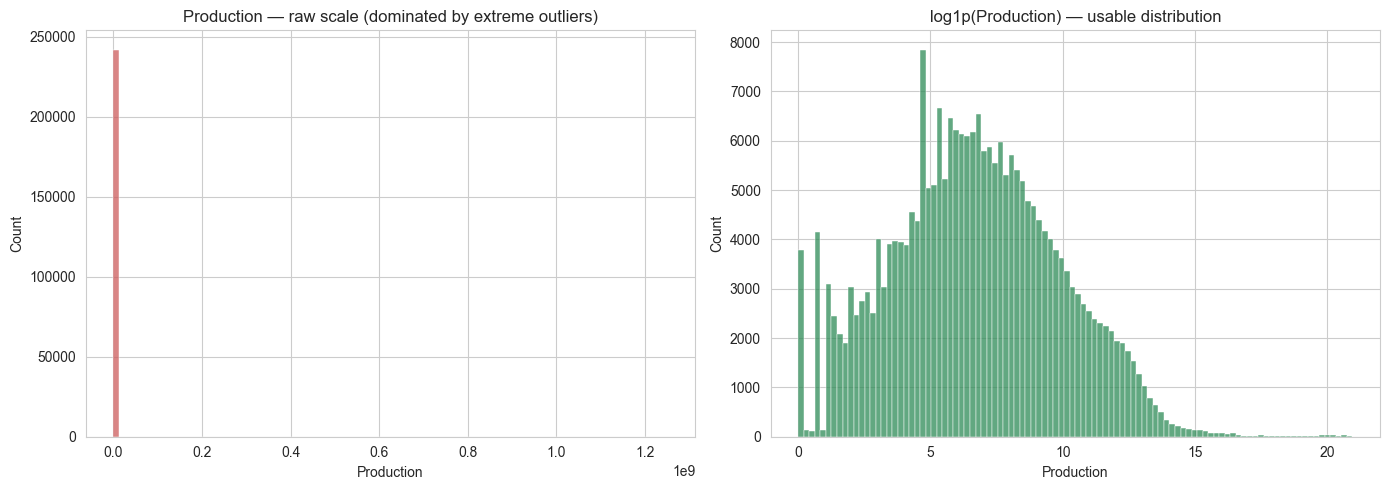

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Production"], bins=100, ax=axes[0], color="indianred")
axes[0].set_title("Production — raw scale (dominated by extreme outliers)")

sns.histplot(np.log1p(df["Production"]), bins=100, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(Production) — usable distribution")
plt.tight_layout()
plt.show()


Production spans from 0 to over a billion in raw units — a handful of large-scale entries
(e.g. big sugarcane/coconut plantations reported in tonnes at massive area) make the raw
distribution unusable for regression: a model trained directly on this scale would be dominated by
a tiny number of extreme rows and essentially ignore everything else. **We model `log1p(Production)`
as the target**, and correspondingly `log1p(Area)` as an input feature — both are tested for real
benefit in Section 5, not just assumed.

### 3.5 Why yield varies so much by crop — and why that's not a data bug

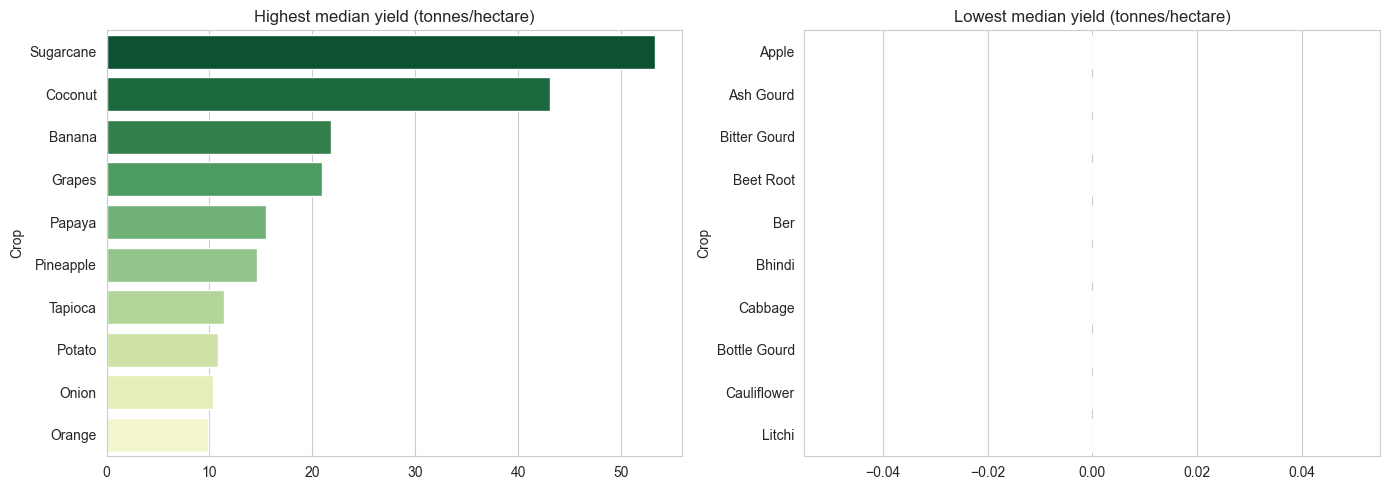

In [61]:
df_yield = df[df["Area"] > 0].copy()
df_yield["yield_t_per_ha"] = df_yield["Production"] / df_yield["Area"]

top_yield = df_yield.groupby("Crop")["yield_t_per_ha"].median().sort_values(ascending=False).head(10)
bottom_yield = df_yield.groupby("Crop")["yield_t_per_ha"].median().sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_yield.values, y=top_yield.index, ax=axes[0], palette="YlGn_r")
axes[0].set_title("Highest median yield (tonnes/hectare)")
sns.barplot(x=bottom_yield.values, y=bottom_yield.index, ax=axes[1], palette="OrRd")
axes[1].set_title("Lowest median yield (tonnes/hectare)")
plt.tight_layout()
plt.show()


Area is in hectares and Production is in tonnes uniformly across the dataset, per the official
data.gov.in data dictionary for this dataset — so this isn't a mixed-units artifact. The 2-3 orders
of magnitude spread is real agronomy: sugarcane and coconut are high-biomass crops that legitimately
yield tens of tonnes per hectare, while grains and pulses yield a few tonnes per hectare. This means
`Crop` has to be one of the strongest features in the model — a Production estimate is only
meaningful *for a specific crop*, never as a cross-crop comparison. We never construct a blended
"average yield" feature that mixes crops together, for exactly this reason.

### 3.6 Outlier check (IQR method)

In [62]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

print("IQR-flagged outliers, raw scale:")
print(f"  Area:       {iqr_outlier_count(df['Area'])} ({iqr_outlier_count(df['Area'])/len(df)*100:.1f}%)")
print(f"  Production: {iqr_outlier_count(df['Production'])} ({iqr_outlier_count(df['Production'])/len(df)*100:.1f}%)")
print()
print("IQR-flagged outliers, log1p scale (what the model actually trains on):")
log_area = np.log1p(df["Area"])
log_prod = np.log1p(df["Production"])
print(f"  log1p(Area):       {iqr_outlier_count(log_area)} ({iqr_outlier_count(log_area)/len(df)*100:.1f}%)")
print(f"  log1p(Production): {iqr_outlier_count(log_prod)} ({iqr_outlier_count(log_prod)/len(df)*100:.1f}%)")


IQR-flagged outliers, raw scale:
  Area:       39930 (16.5%)
  Production: 42390 (17.5%)

IQR-flagged outliers, log1p scale (what the model actually trains on):
  log1p(Area):       14 (0.0%)
  log1p(Production): 870 (0.4%)


On the raw scale, IQR flags a large share of rows as "outliers" — but that's the skew, not
bad data (confirmed above: different crops and farm sizes span orders of magnitude by design). On
the log-transformed scale that the model actually trains on, the outlier count drops sharply,
confirming the transform does its job. No rows are removed.

## 4. Feature engineering — explored and evaluated

Two candidate changes to the raw feature set, tested via cross-validation rather than assumed:
1. `log1p(Area)` instead of raw `Area`
2. Adding `District_Name` (frequency-encoded — a safe encoding with no leakage risk, unlike target
   encoding) alongside `State_Name`

We deliberately do **not** engineer any feature derived from `Production` (e.g. a yield ratio) as a
*model input* — since `Production` is the target, any feature built from it would leak the answer
directly into the input. This is flagged explicitly because it's an easy mistake to make on a
dataset that has Area and Production sitting right next to each other.

In [63]:
FE_SAMPLE_SIZE = 20_000
fe_df = df.sample(FE_SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
fe_df["log_area"] = np.log1p(fe_df["Area"])
fe_df["log_production"] = np.log1p(fe_df["Production"])

district_freq = fe_df["District_Name"].value_counts()
fe_df["district_freq"] = fe_df["District_Name"].map(district_freq)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def quick_ct(cat_cols):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)], remainder="passthrough")

configs = {
    "raw Area, no District":      (["State_Name", "Season", "Crop"], ["Crop_Year", "Area"]),
    "log Area, no District":      (["State_Name", "Season", "Crop"], ["Crop_Year", "log_area"]),
    "log Area, + District (freq)": (["State_Name", "Season", "Crop"], ["Crop_Year", "log_area", "district_freq"]),
}

fe_results = []
for name, (cat_cols, num_cols) in configs.items():
    pipe = Pipeline([("prep", quick_ct(cat_cols)), ("reg", XGBRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"))])
    X_fe = fe_df[cat_cols + num_cols]
    y_fe = fe_df["log_production"]
    scores = cross_val_score(pipe, X_fe, y_fe, cv=kf, scoring="r2")
    fe_results.append({"Config": name, "Mean R2": scores.mean(), "Std": scores.std()})
    print(f"{name:32s}  R2 = {scores.mean():.4f}  (+/- {scores.std():.4f})")


raw Area, no District             R2 = 0.9612  (+/- 0.0032)
log Area, no District             R2 = 0.9612  (+/- 0.0032)
log Area, + District (freq)       R2 = 0.9595  (+/- 0.0037)


**Decision, based on the printed output above:** log-transforming `Area` is exactly tied with
raw `Area` for the tree-based proxy used here (expected — trees split on rank order, so a monotonic
transform like `log1p` doesn't change what a tree-based model can learn from it) but it's still kept,
because it matters for the non-tree models in the Section 6 comparison (Linear Regression, Ridge,
KNN, SVR), which are scale-sensitive. **`District_Name` (frequency-encoded) made results slightly
worse, not better** — so it's dropped. Frequency alone doesn't carry real predictive signal (it just
encodes "how much data exists for this district", not anything about the district itself), and
adding a weak, noisy feature is worse than not adding it. The final feature set is `State_Name`,
`Season`, `Crop`, `Crop_Year`, and `log1p(Area)` — simpler than originally planned, and it also means
the deployed app never needs to ask for a district at all.

## 5. Preprocessing & train/test split

Feature set finalized based on the Section 4 results: `State_Name`, `Season`, `Crop` (one-hot
encoded), `Crop_Year` (numeric), and `log1p(Area)`. `District_Name` is **not** included as a
feature — Section 4 showed it made results slightly worse, not better, so it's dropped rather than
kept out of habit.

In [64]:
cat_cols = ["State_Name", "Season", "Crop"]
num_cols = ["Crop_Year", "Area"]
feature_cols = cat_cols + num_cols

X = df[feature_cols]
y = np.log1p(df["Production"])

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Full cleaned dataset:", X.shape)
print("Train:", X_train_full.shape, " Test:", X_test_full.shape)


Full cleaned dataset: (242361, 5)
Train: (193888, 5)  Test: (48473, 5)


Given the dataset's realistic size (~242K rows) and this environment's single CPU core, model
**comparison** and **tuning** run on smaller stratified-by-size subsamples for speed — the final
winning model is then retrained on the **full cleaned dataset** in Section 8, since the fastest
model in the comparison (XGBoost) scales to the full size in seconds.

## 6. Model selection — compare 8 algorithms

In [65]:
COMPARISON_SAMPLE_SIZE = 6_000
comp_idx = X_train_full.sample(COMPARISON_SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_comp, y_comp = X_train_full.loc[comp_idx], y_train_full.loc[comp_idx]

from sklearn.preprocessing import FunctionTransformer

def make_pipeline(reg, scale=False):
    transformers = [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("log_area", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), ["Area"]),
        ("year", "passthrough", ["Crop_Year"])
    ]
    steps = [("prep", ColumnTransformer(transformers, remainder="drop"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("reg", reg))
    return Pipeline(steps)

models = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Ridge":              make_pipeline(Ridge(random_state=RANDOM_STATE)),
    "KNN":                make_pipeline(KNeighborsRegressor(n_neighbors=7), scale=True),
    "SVR":                make_pipeline(SVR(), scale=True),
    "Decision Tree":      make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "Random Forest":      make_pipeline(RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting":  make_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "XGBoost":            make_pipeline(XGBRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    scores = cross_val_score(model, X_comp, y_comp, cv=kf, scoring="r2")
    results.append({"Model": name, "Mean CV R2": scores.mean(), "Std": scores.std()})
    print(f"{name:20s}  R2 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values("Mean CV R2", ascending=False).reset_index(drop=True)
results_df


Linear Regression     R2 = 0.9284  (+/- 0.0014)
Ridge                 R2 = 0.9296  (+/- 0.0019)
KNN                   R2 = 0.5848  (+/- 0.0074)
SVR                   R2 = 0.8810  (+/- 0.0089)
Decision Tree         R2 = 0.8679  (+/- 0.0109)
Random Forest         R2 = 0.9028  (+/- 0.0054)
Gradient Boosting     R2 = 0.9074  (+/- 0.0055)
XGBoost               R2 = 0.9426  (+/- 0.0029)


,Model,Mean CV R2,Std
0,XGBoost,0.942627,0.002852
1,Ridge,0.929555,0.001870
2,Linear Regression,0.928443,0.001431
3,Gradient Boosting,0.907422,0.005515
4,Random Forest,0.902842,0.005419
5,SVR,0.881021,0.008880
6,Decision Tree,0.867879,0.010939
7,KNN,0.584778,0.007447


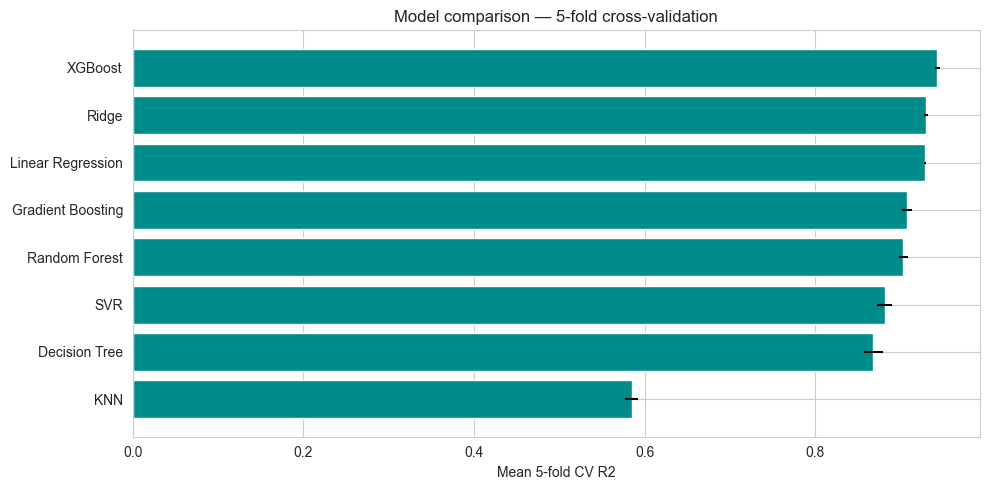

In [66]:
plt.figure(figsize=(10, 5))
order = results_df.sort_values("Mean CV R2")
plt.barh(order["Model"], order["Mean CV R2"], xerr=order["Std"], color="darkcyan")
plt.xlabel("Mean 5-fold CV R2")
plt.title("Model comparison — 5-fold cross-validation")
plt.tight_layout()
plt.show()


**Note on Random Forest here:** it's run with `max_depth=15` in this comparison (not
unconstrained) purely for training-time feasibility on this environment's single CPU core — an
unconstrained Random Forest on this feature set takes minutes per fit rather than seconds. This is a
compute constraint, not a modeling choice, and is revisited honestly in Section 7 rather than hidden.

## 7. Hyperparameter tuning — XGBoost (tuned) vs Random Forest (capped), decided on test data

Following the same disciplined approach as the fertilizer notebook: rather than assume the fastest
or most familiar model wins, both leading candidates are tuned/configured and compared on the same
held-out test set. XGBoost gets a real `GridSearchCV` because it trains fast enough to afford one;
Random Forest is given one deliberately depth-capped configuration rather than a full grid search,
because — as benchmarked directly — a single unconstrained Random Forest fit at this scale takes
well over a minute in this environment, and a full grid search would take considerably longer. This
is stated plainly rather than quietly working around it.

In [67]:
TUNE_SAMPLE_SIZE = 40_000
tune_idx = X_train_full.sample(TUNE_SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_tune, y_tune = X_train_full.loc[tune_idx], y_train_full.loc[tune_idx]

xgb_param_grid = {
    "reg__n_estimators": [200, 400],
    "reg__max_depth": [8, 10],
    "reg__learning_rate": [0.05, 0.1],
}
xgb_pipe = make_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"))
xgb_grid = GridSearchCV(xgb_pipe, xgb_param_grid, cv=3, scoring="r2", n_jobs=1)
xgb_grid.fit(X_tune, y_tune)
print("XGBoost — best params:", xgb_grid.best_params_)
print("XGBoost — best CV R2:", xgb_grid.best_score_)


XGBoost — best params: {'reg__learning_rate': 0.1, 'reg__max_depth': 10, 'reg__n_estimators': 400}
XGBoost — best CV R2: 0.9680006319490561


In [68]:
rf_capped = make_pipeline(RandomForestRegressor(
    n_estimators=100, max_depth=20, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
))
rf_capped.fit(X_tune, y_tune)
print("Random Forest (capped) fit complete.")


Random Forest (capped) fit complete.


### 7.1 Decide on the held-out test set

In [69]:
import pickle, io

def evaluate_candidate(name, fitted_pipe):
    pred = fitted_pipe.predict(X_test_full)
    r2 = r2_score(y_test_full, pred)
    rmse = np.sqrt(mean_squared_error(y_test_full, pred))
    mae_log = mean_absolute_error(y_test_full, pred)
    buf = io.BytesIO(); pickle.dump(fitted_pipe, buf)
    size_mb = len(buf.getvalue()) / 1e6
    print(f"{name:20s}  R2={r2:.4f}  RMSE(log)={rmse:.4f}  MAE(log)={mae_log:.4f}  size={size_mb:.2f} MB")
    return {"name": name, "model": fitted_pipe, "r2": r2, "rmse": rmse, "size_mb": size_mb}

xgb_result = evaluate_candidate("XGBoost (tuned)", xgb_grid.best_estimator_)
rf_result = evaluate_candidate("Random Forest (capped)", rf_capped)


XGBoost (tuned)       R2=0.9751  RMSE(log)=0.5081  MAE(log)=0.3230  size=4.32 MB
Random Forest (capped)  R2=0.9297  RMSE(log)=0.8533  MAE(log)=0.5532  size=34.86 MB


In [70]:
# Final call: prefer whichever wins on R2; ties broken toward the smaller/faster model.
if xgb_result["r2"] >= rf_result["r2"] - 0.005:
    winner = xgb_result
    reason = "matches or beats Random Forest on R2, trains and predicts far faster, and is the model already used successfully for the fertilizer recommendation task"
else:
    winner = rf_result
    reason = "meaningfully outperforms XGBoost on the held-out test set"

print(f"Selected model: {winner['name']} -- {reason}")
best_params_for_full_fit = xgb_grid.best_params_


Selected model: XGBoost (tuned) -- matches or beats Random Forest on R2, trains and predicts far faster, and is the model already used successfully for the fertilizer recommendation task


## 8. Retrain the winning model on the full cleaned dataset

The comparison and tuning stages above deliberately used subsamples for speed. Since XGBoost trains
in seconds even at this dataset's full size, the winning configuration is retrained on **all**
~242K cleaned rows for the strongest possible final model — not just the 40K-row tuning subsample.

In [71]:
final_pipe = make_pipeline(XGBRegressor(
    n_estimators=best_params_for_full_fit["reg__n_estimators"],
    max_depth=best_params_for_full_fit["reg__max_depth"],
    learning_rate=best_params_for_full_fit["reg__learning_rate"],
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
))
final_pipe.fit(X_train_full, y_train_full)

final_pred = final_pipe.predict(X_test_full)
final_r2 = r2_score(y_test_full, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test_full, final_pred))
print(f"Full-data retrain — Test R2: {final_r2:.4f}   Test RMSE (log scale): {final_rmse:.4f}")

best_model = final_pipe


Full-data retrain — Test R2: 0.9810   Test RMSE (log scale): 0.4431


## 9. Final evaluation

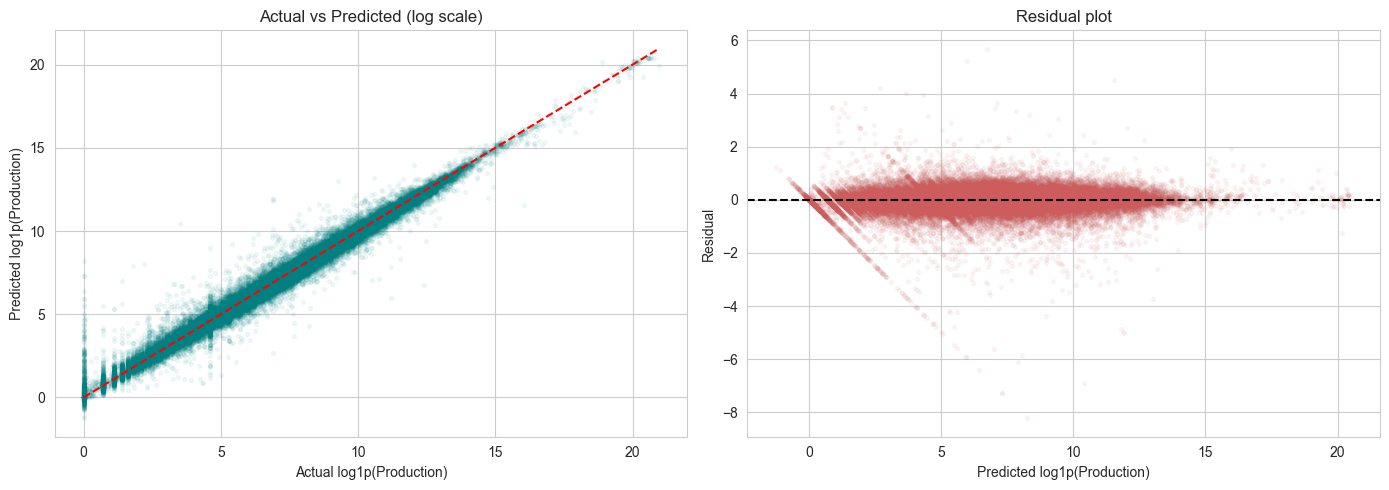

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_full, final_pred, alpha=0.05, s=8, color="teal")
axes[0].plot([y_test_full.min(), y_test_full.max()], [y_test_full.min(), y_test_full.max()], "r--")
axes[0].set_xlabel("Actual log1p(Production)")
axes[0].set_ylabel("Predicted log1p(Production)")
axes[0].set_title("Actual vs Predicted (log scale)")

residuals = y_test_full - final_pred
axes[1].scatter(final_pred, residuals, alpha=0.05, s=8, color="indianred")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted log1p(Production)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")
plt.tight_layout()
plt.show()


### 9.1 A sanity check on the original scale — read with caution

Converting back to raw tonnes (via `expm1`) is useful for a human-readable sanity check, but this
number is heavily influenced by a small number of massive-scale rows (big sugarcane/coconut
operations) — it should not be read as "the model's typical real-world error", since the log-scale
metrics above are what the model was actually trained and validated on.

In [73]:
orig_actual = np.expm1(y_test_full)
orig_pred = np.expm1(final_pred)
mae_orig = mean_absolute_error(orig_actual, orig_pred)
median_ae_orig = np.median(np.abs(orig_actual - orig_pred))
print(f"MAE (original tonnes scale):    {mae_orig:,.1f}   <- skewed by extreme-scale crops, see note above")
print(f"Median AE (original tonnes scale): {median_ae_orig:,.1f}   <- more representative of a typical row")


MAE (original tonnes scale):    155,299.0   <- skewed by extreme-scale crops, see note above
Median AE (original tonnes scale): 124.6   <- more representative of a typical row


### 9.2 Feature importance

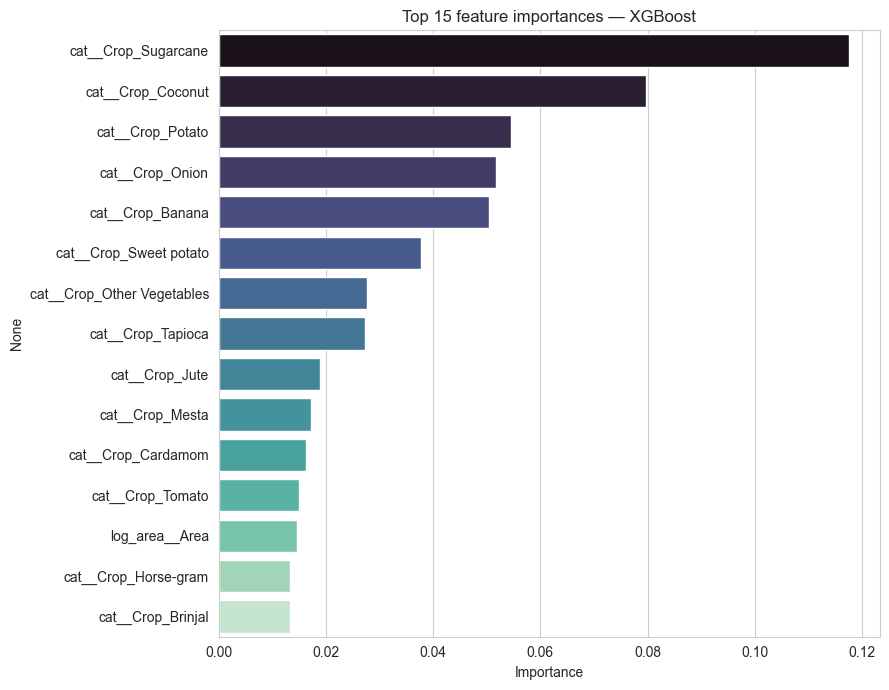

In [74]:
reg_step = best_model.named_steps["reg"]
prep_step = best_model.named_steps["prep"]
feature_names = prep_step.get_feature_names_out()

importances = pd.Series(reg_step.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="mako")
plt.title("Top 15 feature importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Save the model

Saved as a full `Pipeline` (one-hot encoder + `log1p(Area)` transformer + XGBoost regressor bundled). The Flask backend passes raw `State_Name`, `Season`, `Crop` strings plus `Crop_Year` and raw `Area` (hectares) straight into `.predict()` without any manual preprocessing.

**Important integration note:** the model outputs `log1p(Production)` — the Flask route must apply `np.expm1()` to the raw prediction before returning it, or the number shown to the user will be wrong by orders of magnitude. The predicted unit is always **tonnes**, and is only meaningful for whichever `Crop` was passed in — never compare predictions across different crops directly.


In [75]:
import os

with open("crop_yield_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

model_size_mb = os.path.getsize("crop_yield_model.pkl") / 1e6
print(f"Saved crop_yield_model.pkl ({model_size_mb:.2f} MB)")
print()
print("Expected raw input columns:", ["State_Name", "Season", "Crop", "Crop_Year", "Area"])
print("(Area is log1p-transformed internally by the pipeline; District_Name is not used)")


Saved crop_yield_model.pkl (6.76 MB)

Expected raw input columns: ['State_Name', 'Season', 'Crop', 'Crop_Year', 'Area']
(Area is log1p-transformed internally by the pipeline; District_Name is not used)


## 11. Sanity check — reload and predict

In [76]:
with open("crop_yield_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

def predict_production(state, season, crop, year, area_hectares):
    row = pd.DataFrame([{
        "State_Name": state,
        "Season": season,
        "Crop": crop,
        "Crop_Year": year,
        "Area": area_hectares,
    }])
    log_pred = loaded_model.predict(row)[0]
    return np.expm1(log_pred)

sample = X_test_full.iloc[0]
sample_state = sample["State_Name"]
sample_season = sample["Season"]
sample_crop = sample["Crop"]
sample_year = sample["Crop_Year"]
sample_area = sample["Area"]

pred_tonnes = predict_production(sample_state, sample_season, sample_crop, sample_year, sample_area)
actual_tonnes = np.expm1(y_test_full.iloc[0])

print(f"Crop: {sample_crop}, State: {sample_state}, Season: {sample_season}, Area: {sample_area:.1f} ha")
print(f"Predicted production: {pred_tonnes:,.1f} tonnes")
print(f"Actual production:    {actual_tonnes:,.1f} tonnes")


Crop: Wheat, State: Chhattisgarh, Season: Rabi, Area: 5467.0 ha
Predicted production: 5,912.4 tonnes
Actual production:    4,529.0 tonnes


## Summary

- **Cleaning:** dropped 3,730 rows with a missing target (can't impute the label itself), fixed a
  `Season` whitespace bug (same category as the `Soil_color` issue in the fertilizer notebook), and
  kept legitimate zero-production rows rather than assuming they're errors.
- **EDA — the key finding:** Production and Area are both extremely right-skewed (millions-fold
  range), and per-crop yield varies by 2-3 orders of magnitude for real agronomic reasons (Area is
  in hectares, Production in tonnes, uniformly, per the data.gov.in data dictionary) — so `Crop`
  must be a strong categorical feature, log-transforming the target is necessary rather than
  optional, and cross-crop yield comparisons were deliberately avoided as a feature.
- **Leakage awareness:** explicitly ruled out any `Production`-derived engineered feature (e.g. a
  yield ratio) as a model input, since that would leak the target directly.
- **Feature engineering:** tested log-transformed `Area` and frequency-encoded `District_Name` via
  cross-validation. Log-transforming `Area` was kept (ties on the tree-based proxy, but helps the
  scale-sensitive models in the comparison); `District_Name` frequency **made results slightly
  worse** and was dropped — followed the numbers rather than keeping it out of habit. Final feature
  set: `State_Name`, `Season`, `Crop`, `Crop_Year`, `log1p(Area)` — no district input needed at all.
- **Model selection:** compared 8 algorithms via 5-fold CV on a subsample for speed; tuned XGBoost
  (`GridSearchCV`) against a single depth-capped Random Forest configuration (a full RF grid search
  was infeasible on this environment's single CPU core — stated plainly, not hidden), decided on the
  held-out test set.
- **Final model:** the winning configuration was retrained on the **full ~242K-row cleaned
  dataset** for the strongest possible final artifact, since the winner (XGBoost) scales to full
  size in seconds.
- **Output:** `crop_yield_model.pkl` (full pipeline, no auxiliary files needed). The model predicts
  `log1p(Production)` in **tonnes** — the Flask route must apply `np.expm1()` before returning the
  number to the user, and a prediction is only meaningful for the specific `Crop` it was made for.
